In [1]:
import pandas as pd                # for dataframes and data wrangling
import numpy as np                 # for numeric helpers
import matplotlib.pyplot as plt    # for plotting

In [2]:
pd.set_option("display.max_columns", 100) #to increase the width of the columns in the bar chart
pd.set_option("display.width", 120)

EDA

In [3]:
df = pd.read_csv("Fraud_Data.csv", parse_dates=["signup_time", "purchase_time"]) #parse_dates converts string to datetime objects to do mathematical calculations

print("Shape (rows, cols):", df.shape)     # checking the size of the dataset
print("\nFirst 5 rows:\n", df.head())      # prints first 5 rows

Shape (rows, cols): (151112, 11)

First 5 rows:
    user_id         signup_time       purchase_time  purchase_value      device_id source browser sex  age  \
0    22058 2015-02-24 22:55:49 2015-04-18 02:47:11              34  QVPSPJUOCKZAR    SEO  Chrome   M   39   
1   333320 2015-06-07 20:39:50 2015-06-08 01:38:54              16  EOGFQPIZPYXFZ    Ads  Chrome   F   53   
2     1359 2015-01-01 18:52:44 2015-01-01 18:52:45              15  YSSKYOSJHPPLJ    SEO   Opera   M   53   
3   150084 2015-04-28 21:13:25 2015-05-04 13:54:50              44  ATGTXKYKUDUQN    SEO  Safari   M   41   
4   221365 2015-07-21 07:09:52 2015-09-09 18:40:53              39  NAUITBZFJKHWW    Ads  Safari   M   45   

     ip_address  class  
0  7.327584e+08      0  
1  3.503114e+08      0  
2  2.621474e+09      1  
3  3.840542e+09      0  
4  4.155831e+08      0  


In [5]:
print("\ndtypes & non-null counts")
df.info()                                   # shows dtype and non-null counts

print("\n=== Missing values per column")
missing = df.isna().sum().sort_values(ascending=False)
print(missing[missing > 0])                 # print only columns that have missing values (if any)




dtypes & non-null counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[ns]
 2   purchase_time   151112 non-null  datetime64[ns]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  object        
 5   source          151112 non-null  object        
 6   browser         151112 non-null  object        
 7   sex             151112 non-null  object        
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(4), object(4)
memory usage: 12.7+ MB

=== Missing values per column
Series([], dtype: int64)


In [ ]:
#to check if the time to purchase is either too short or too long
df["time_to_purchase"] = (df["purchase_time"] - df["signup_time"]).dt.total_seconds() 
df["purchase_hour"] = df["purchase_time"].dt.hour
df["purchase_day"]  = df["purchase_time"].dt.day_name()
print("\nAdded columns: ['time_to_purchase', 'purchase_hour', 'purchase_day']")




Added columns: ['time_to_purchase', 'purchase_hour', 'purchase_day']



Class balance:
 class
0    136961
1     14151
Name: count, dtype: int64


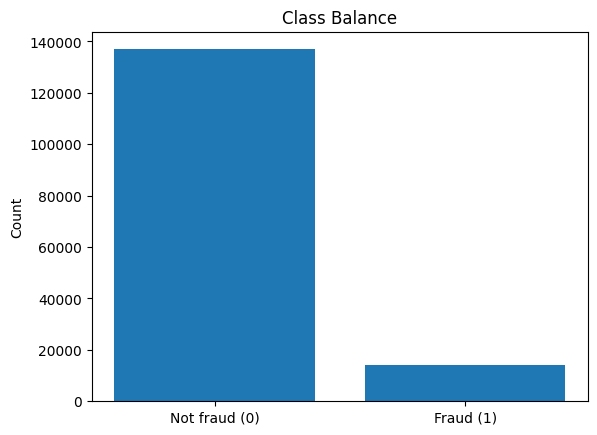

In [14]:
# checking class imbalance by counting how many 0 (not fraud) vs 1 (fraud)
counts = df["class"].value_counts().sort_index()  # index 0 then 1
print("\nClass balance:\n", counts)

# Bar chart of class balance
plt.figure()
plt.bar(["Not fraud (0)", "Fraud (1)"], counts.values)
plt.title("Class Balance")
plt.ylabel("Count")
plt.show()



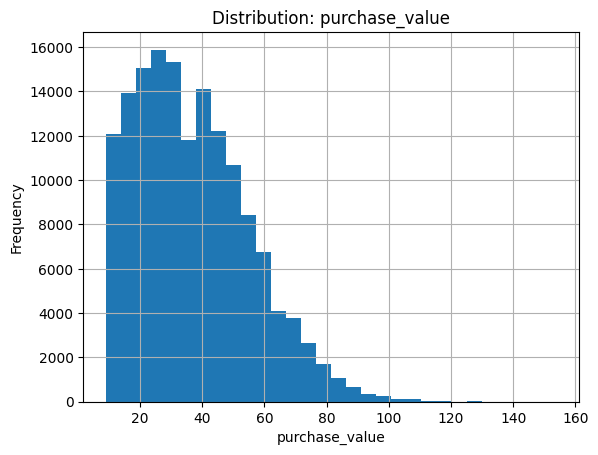

In [24]:
# Histogram: purchase_value
plt.figure()
df["purchase_value"].dropna().hist(bins=30)
plt.title("Distribution: purchase_value")
plt.xlabel("purchase_value")
plt.ylabel("Frequency")
plt.show()

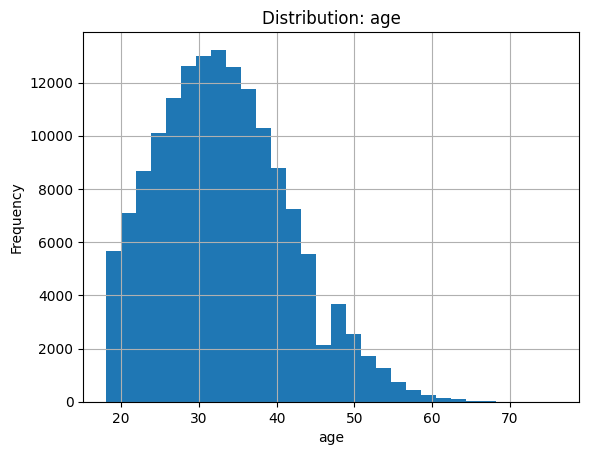

In [25]:
# Histogram: age
plt.figure()
df["age"].dropna().hist(bins=30)
plt.title("Distribution: age")
plt.xlabel("age")
plt.ylabel("Frequency")
plt.show()

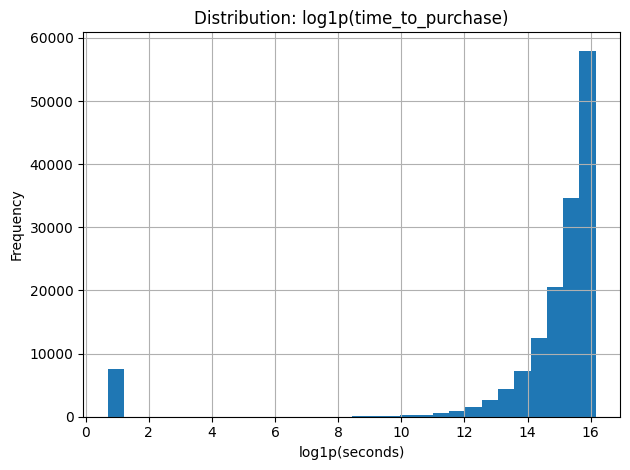

In [ ]:
# Histogram: time_to_purchase 
plt.figure()
np.log1p(df["time_to_purchase"].clip(lower=0)).dropna().hist(bins=30)
plt.title("Distribution: log1p(time_to_purchase)")
plt.xlabel("log1p(seconds)")
plt.ylabel("Frequency")
plt.show()

FEATURE ENGINEERING


Value counts for 'source':
 source
SEO       60615
Ads       59881
Direct    30616
Name: count, dtype: int64


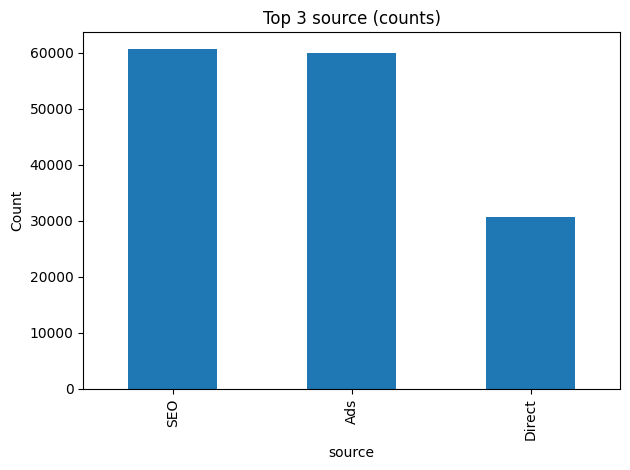


Fraud rate by source (top 10):
 source
Direct    0.105370
Ads       0.092066
SEO       0.089285
Name: class, dtype: float64


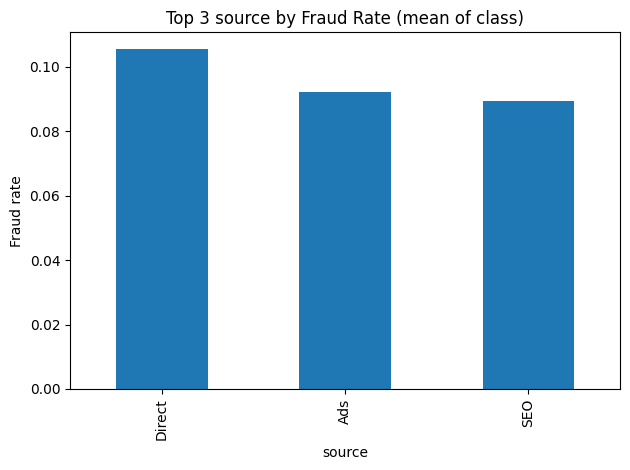


Value counts for 'browser':
 browser
Chrome     61432
IE         36727
Safari     24667
FireFox    24610
Opera       3676
Name: count, dtype: int64


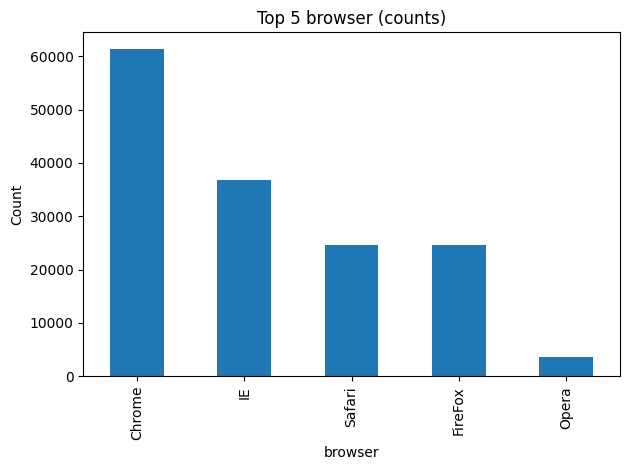


Fraud rate by browser (top 10):
 browser
Chrome     0.098792
FireFox    0.095165
Safari     0.090201
Opera      0.089227
IE         0.086775
Name: class, dtype: float64


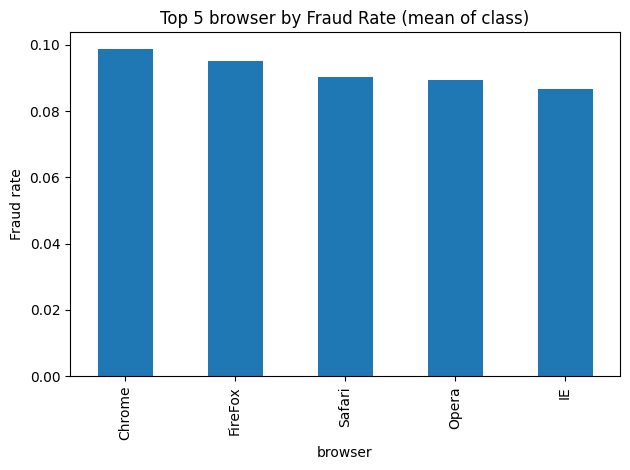


Value counts for 'sex':
 sex
M    88293
F    62819
Name: count, dtype: int64


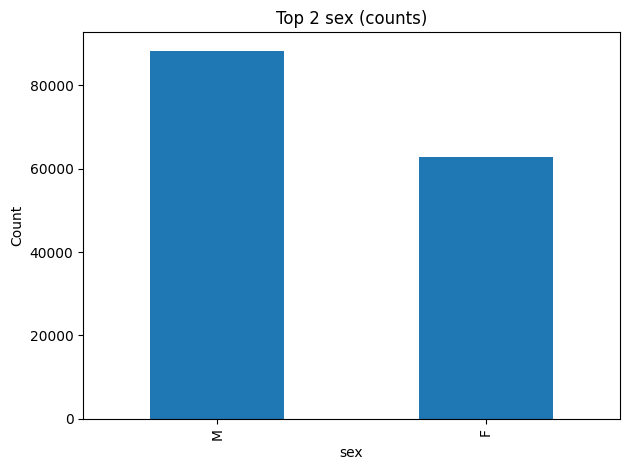


Fraud rate by sex (top 10):
 sex
M    0.095523
F    0.091007
Name: class, dtype: float64


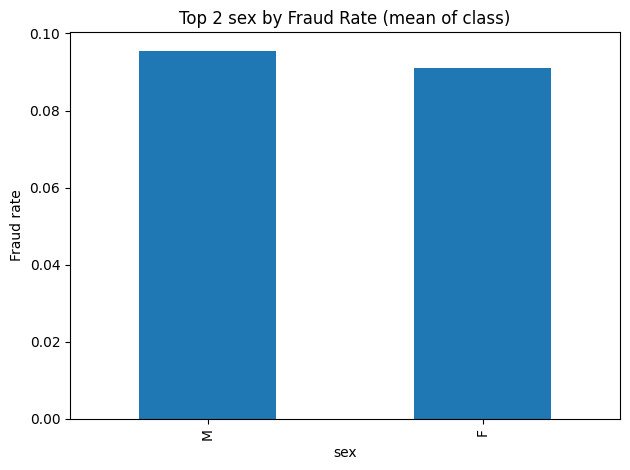

In [11]:
#categorical columns
cat_cols = [c for c in ["source", "browser", "sex"] if c in df.columns]

for col in cat_cols:
    print(f"\nValue counts for '{col}':\n", df[col].value_counts())

    # Top categories bar chart (counts)
    top_counts = df[col].value_counts().head(10)
    plt.figure()
    top_counts.plot(kind="bar")
    plt.title(f"Top {len(top_counts)} {col} (counts)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # Fraud rate by category (mean of class = probability of fraud)
    fraud_rate = df.groupby(col)["class"].mean().sort_values(ascending=False).head(10)
    print(f"\nFraud rate by {col} (top 10):\n", fraud_rate)

    plt.figure()
    fraud_rate.plot(kind="bar")
    plt.title(f"Top {len(fraud_rate)} {col} by Fraud Rate (mean of class)")
    plt.ylabel("Fraud rate")
    plt.tight_layout()
    plt.show()

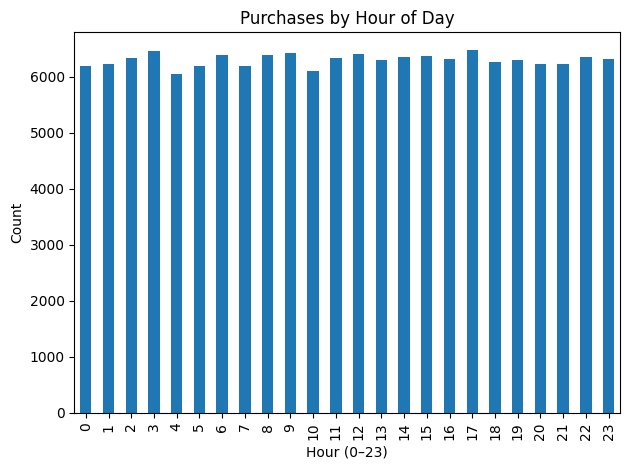

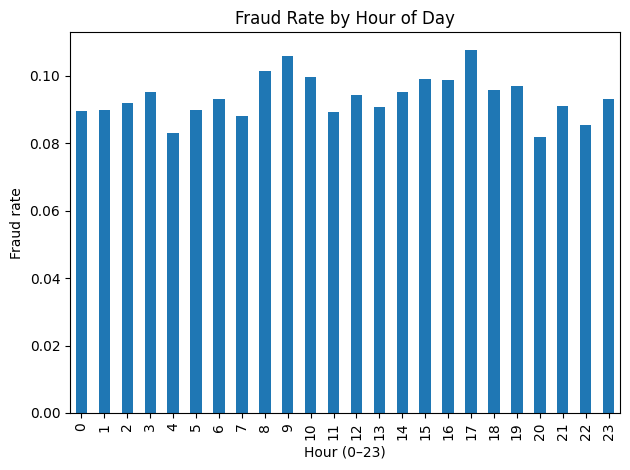

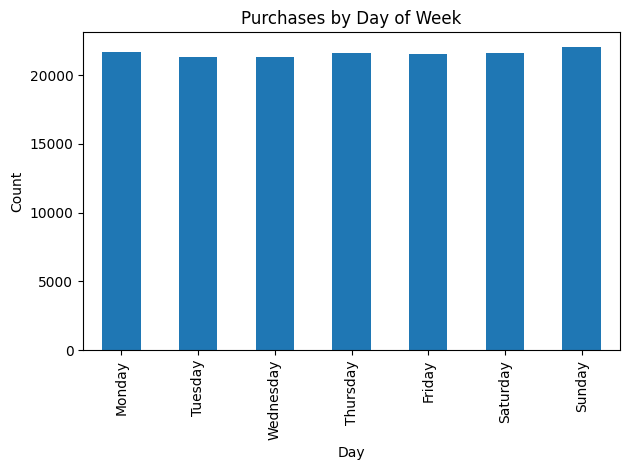

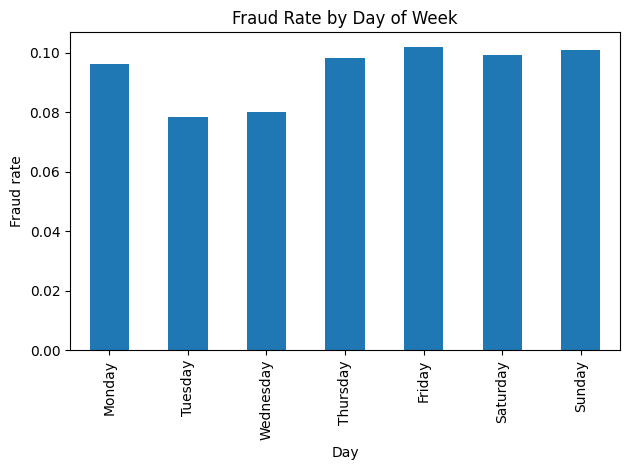

In [12]:
#checking purchase time pattern
hour_counts = df["purchase_hour"].value_counts().sort_index()
plt.figure()
hour_counts.plot(kind="bar")
plt.title("Purchases by Hour of Day")
plt.xlabel("Hour (0–23)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Fraud rate by hour
hour_fraud_rate = df.groupby("purchase_hour")["class"].mean()
plt.figure()
hour_fraud_rate.plot(kind="bar")
plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour (0–23)")
plt.ylabel("Fraud rate")
plt.tight_layout()
plt.show()

# Counts by day of week (order the days manually for readability)
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_counts = df["purchase_day"].value_counts()
day_counts = day_counts.reindex(day_order)
plt.figure()
day_counts.plot(kind="bar")
plt.title("Purchases by Day of Week")
plt.xlabel("Day")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Fraud rate by day of week
day_fraud_rate = df.groupby("purchase_day")["class"].mean().reindex(day_order)
plt.figure()
day_fraud_rate.plot(kind="bar")
plt.title("Fraud Rate by Day of Week")
plt.xlabel("Day")
plt.ylabel("Fraud rate")
plt.tight_layout()
plt.show()